In [ ]:
#[Step 1] Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



=== Logistic Regression ===
Accuracy: 0.9767441860465116
F1 Score: 0.96875
ROC-AUC Score: 0.998263888888889
Confusion Matrix:
 [[53  1]
 [ 1 31]]


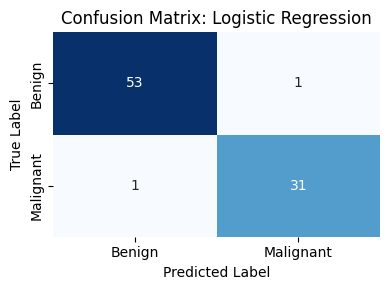


=== Random Forest ===
Accuracy: 0.9651162790697675
F1 Score: 0.9523809523809523
ROC-AUC Score: 0.9953703703703703
Confusion Matrix:
 [[53  1]
 [ 2 30]]


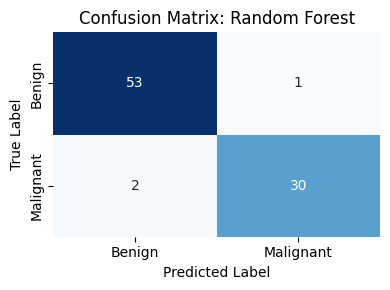


=== SVM ===
Accuracy: 0.9767441860465116
F1 Score: 0.967741935483871
ROC-AUC Score: 0.9994212962962963
Confusion Matrix:
 [[54  0]
 [ 2 30]]


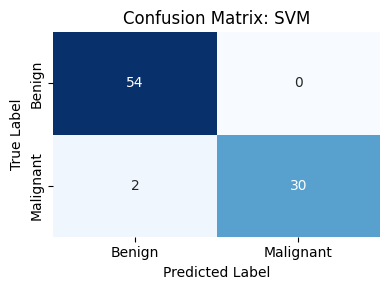

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:27:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== XGBoost ===
Accuracy: 0.9767441860465116
F1 Score: 0.96875
ROC-AUC Score: 0.9971064814814815
Confusion Matrix:
 [[53  1]
 [ 1 31]]


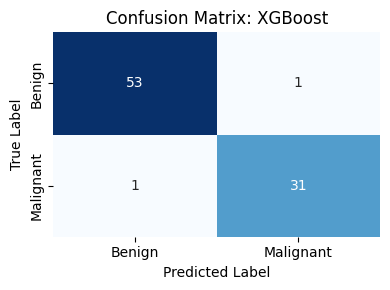


=== MLP ===
Accuracy: 0.9883720930232558
F1 Score: 0.9841269841269841
ROC-AUC Score: 0.9994212962962963
Confusion Matrix:
 [[54  0]
 [ 1 31]]


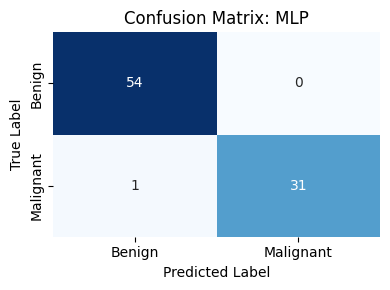


Model Comparison Table (sorted by ROC-AUC):
                 Model  Accuracy  F1-Score   ROC-AUC
2                  SVM  0.976744  0.967742  0.999421
4                  MLP  0.988372  0.984127  0.999421
0  Logistic Regression  0.976744  0.968750  0.998264
3              XGBoost  0.976744  0.968750  0.997106
1        Random Forest  0.965116  0.952381  0.995370


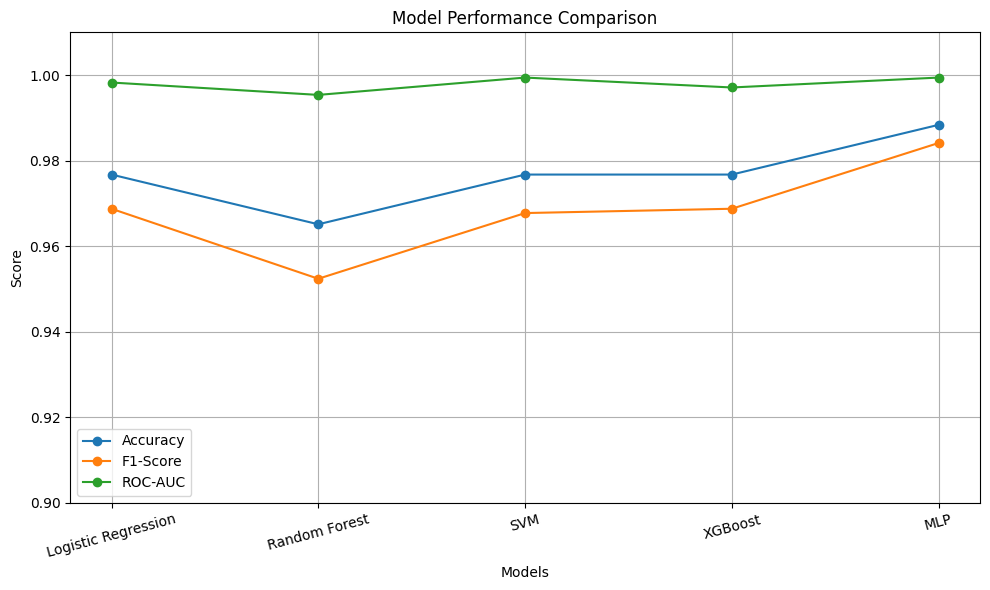

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Load and clean dataset
df = pd.read_csv("/content/drive/MyDrive/ML/data.csv")
df.drop(['Unnamed: 32', 'id'], axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

# Features and label separation
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Feature normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified data splitting
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)

# Define classification models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True),
    "XGBoost": XGBClassifier(learning_rate=0.1, max_depth=4, use_label_encoder=False, eval_metric='logloss'),
    "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, early_stopping=True, random_state=42)
}

# Function to plot confusion matrix
def plot_conf_matrix(cm, model_name):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

# Train and evaluate models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc = roc_auc_score(y_val, y_proba)
    cm = confusion_matrix(y_val, y_pred)

    results.append([name, acc, f1, roc])

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("ROC-AUC Score:", roc)
    print("Confusion Matrix:\n", cm)

    plot_conf_matrix(cm, name)

# Create and show comparison table
result_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-Score", "ROC-AUC"])
print("\nModel Comparison Table (sorted by ROC-AUC):")
print(result_df.sort_values(by="ROC-AUC", ascending=False))

# Plot performance comparison graph
plt.figure(figsize=(10, 6))
for metric in ["Accuracy", "F1-Score", "ROC-AUC"]:
    plt.plot(result_df["Model"], result_df[metric], marker='o', label=metric)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0.9, 1.01)
plt.legend()
plt.grid(True)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
